# 123 — Kmerseek Pfam Subdomain Benchmark: Divergence vs AUC

Evaluates kmerseek's ability to detect shared Pfam subdomains between proteins
that are **not** full-length homologs, across the full spectrum of evolutionary
divergence from human, and across multiple HP k-sizes.

**Ground truth**: `results/pfam_benchmark/pairs/human_vs_{species}_ground_truth.parquet`  
**Kmerseek results**: `~/data/qfo-pfam-benchmark/kmerseek-results/human_vs_{species}.hp.k{ksize}.results.csv.gz`  

**Key figures**:
- Fig 1a: AUC vs MYA, one line per k-size (best scoring method) — shows effective range of each k
- Fig 1b: AUC vs MYA, one line per scoring method (best k) — shows best scoring strategy
- Fig 2:  Per-species ROC/PR curves (best k, best score)
- Fig 3:  Domain length × detection rate, faceted by divergence distance
- Fig 4:  Score distribution violins per species

In [58]:
from pathlib import Path
import json
import warnings

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

In [59]:
REPO_ROOT = Path("..")  # notebooks/ → repo root
BENCHMARK_DIR = REPO_ROOT / "results/pfam_benchmark"
PAIRS_DIR = BENCHMARK_DIR / "pairs"
ANNOT_DIR = BENCHMARK_DIR / "annotations"
MERGED_DIR = BENCHMARK_DIR / "merged"
SPECIES_META = REPO_ROOT / "data/species_metadata.json"
MERGED_DIR.mkdir(exist_ok=True)

# Kmerseek CSV.gz files: human_vs_{species}.hp.k{ksize}.results.csv.gz
KMERSEEK_RESULTS_DIR = Path.home() / "data/qfo-pfam-benchmark/kmerseek-results"

KSIZES = [10, 12, 14, 16, 18, 20, 24, 28, 32, 36, 40]
ENCODING = "hp"

with open(SPECIES_META) as f:
    META = json.load(f)

# Protein counts from QFO 2020 fasta files (~/data/quest-for-orthologs/
# QfO_release_2020_04_with_updated_UP000008143/{kingdom}/{proteome}_{taxid}.fasta).
# Used as Bonferroni/BH correction denominators.
N_PROTEINS: dict[str, int] = {
    "human": 20600,  # UP000005640_9606.fasta
    "mouse": 21989,  # UP000000589_10090.fasta
    "chicken": 18116,  # UP000000539_9031.fasta
    "zebrafish": 25698,  # UP000000437_7955.fasta
    "ciona": 16678,  # UP000008144_7719.fasta
    "fly": 13811,  # UP000000803_7227.fasta
    "worm": 19819,  # UP000001940_6239.fasta
    "yeast": 6049,  # UP000002311_559292.fasta
    "arabidopsis": 27500,  # UP000006548_3702.fasta
    "ecoli": 4391,  # UP000000625_83333.fasta
}
N_HUMAN = N_PROTEINS["human"]

# Load pfam summaries for annotation-coverage diagnostics (not for correction denominators)
PFAM_SUMMARY: dict[str, dict] = {}
for _sp in list(META.keys()):
    _p = ANNOT_DIR / f"{_sp}_pfam_summary.json"
    if _p.exists():
        with open(_p) as _f:
            PFAM_SUMMARY[_sp] = json.load(_f)

SPECIES_ORDER = sorted([s for s in META if s != "human"], key=lambda s: META[s]["mya"])

print(f"K-sizes: {KSIZES}")
print(f"Species ({len(SPECIES_ORDER)}):")
for s in SPECIES_ORDER:
    print(
        f"  {s:12s}  {META[s]['mya']:5d} MYA  n={N_PROTEINS.get(s,'?')}  {META[s]['name']}"
    )

K-sizes: [10, 12, 14, 16, 18, 20, 24, 28, 32, 36, 40]
Species (9):
  mouse           100 MYA  n=21989  Mus musculus
  chicken         300 MYA  n=18116  Gallus gallus
  zebrafish       430 MYA  n=25698  Danio rerio
  ciona           550 MYA  n=16678  Ciona intestinalis
  fly             600 MYA  n=13811  Drosophila melanogaster
  worm            650 MYA  n=19819  Caenorhabditis elegans
  yeast           900 MYA  n=6049  Saccharomyces cerevisiae S288C
  arabidopsis    1500 MYA  n=27500  Arabidopsis thaliana
  ecoli          2000 MYA  n=4391  Escherichia coli K-12


## Scoring helpers

In [60]:
def extract_accession_expr(col: str) -> pl.Expr:
    """Extract UniProt accession from kmerseek query_name / target_name."""
    return (
        pl.col(col)
        .str.extract(r"(?:sp|tr)\|([A-Z0-9]+)\|", group_index=1)
        .fill_null(
            pl.col(col).str.extract(
                r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z][A-Z0-9]{2}[0-9]){1,2})",
                group_index=1,
            )
        )
    )


def add_composite_scores(df: pl.DataFrame) -> pl.DataFrame:
    """
    All scores oriented so HIGHER = more likely true positive.
    `containment` = containment of query k-mers in target.
    `bonf_pvalue` and `bh_pvalue` must already be present (added in load_and_merge).
    """
    eps = 1e-9
    return df.with_columns(
        [
            # a) enrichment x containment / mean_matched_kmer_freq
            (
                pl.col("enrichment")
                * pl.col("containment")
                / (pl.col("mean_matched_kmer_freq") + eps)
            ).alias("score_enr_cont_freq"),
            # b) enrichment x containment
            (pl.col("enrichment") * pl.col("containment")).alias("score_enr_cont"),
            # c) -log10(p) x containment  (uncorrected)
            (
                -pl.col("poisson_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
                * pl.col("containment")
            ).alias("score_neglogp_cont"),
            # d) query_tfidf x containment
            (pl.col("query_tfidf") * pl.col("containment")).alias("score_tfidf_cont"),
            # e) -log10(p) alone  (uncorrected)
            (
                -pl.col("poisson_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
            ).alias("score_neglogp"),
            # f) -log10(p_bonf)  (Bonferroni: p x n_human x n_species)
            (
                -pl.col("bonf_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
            ).alias("score_bonf_neglogp"),
            # g) -log10(p_bonf) x containment
            (
                -pl.col("bonf_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
                * pl.col("containment")
            ).alias("score_bonf_neglogp_cont"),
            # h) -log10(q_bh)  (Benjamini-Hochberg FDR: q = p * n_bonf / rank)
            (
                -pl.col("bh_pvalue").clip(lower_bound=1e-300).log(base=10).fill_nan(0.0)
            ).alias("score_bh_neglogq"),
            # i) -log10(q_bh) x containment
            (
                -pl.col("bh_pvalue").clip(lower_bound=1e-300).log(base=10).fill_nan(0.0)
                * pl.col("containment")
            ).alias("score_bh_neglogq_cont"),
        ]
    )


SCORE_COLS = [
    "score_enr_cont_freq",
    "score_enr_cont",
    "score_neglogp_cont",
    "score_tfidf_cont",
    "score_neglogp",
    "score_bonf_neglogp",
    "score_bonf_neglogp_cont",
    "score_bh_neglogq",
    "score_bh_neglogq_cont",
    "enrichment",
    "containment",
    "jaccard",
]
SCORE_LABELS = {
    "score_enr_cont_freq": "enrichment x containment / freq",
    "score_enr_cont": "enrichment x containment",
    "score_neglogp_cont": "-log10(p) x containment",
    "score_tfidf_cont": "query_tfidf x containment",
    "score_neglogp": "-log10(p)",
    "score_bonf_neglogp": "-log10(p*N_bonf)",
    "score_bonf_neglogp_cont": "-log10(p*N_bonf) x containment",
    "score_bh_neglogq": "-log10(q_BH)",
    "score_bh_neglogq_cont": "-log10(q_BH) x containment",
    "enrichment": "enrichment",
    "containment": "containment",
    "jaccard": "jaccard",
}

KS_COLS = [
    "enrichment",
    "containment",
    "jaccard",
    "query_tfidf",
    "mean_matched_kmer_freq",
    "sum_matched_kmer_freq",
    "expected_shared_kmers",
    "poisson_pvalue",
]

## Load and merge all (species × ksize) combinations

In [61]:
def load_and_merge(species: str, ksize: int) -> pl.DataFrame | None:
    """
    Load ground truth + kmerseek results for (species, ksize).
    Left-join on ground truth; undetected pairs filled with p=1, scores=0.

    Multiple-testing corrections (denominator = n_human x n_species):
      bonf_pvalue = min(1, p * n_bonf)            -- Bonferroni
      bh_pvalue   = min(1, p * n_bonf / rank(p))  -- Benjamini-Hochberg FDR
        where rank is ordinal rank of p across all n_bonf tests (unobserved
        pairs have p=1, so observed pairs with p<1 rank below them).
    """
    gt_path = PAIRS_DIR / f"human_vs_{species}_ground_truth.parquet"
    csv_path = (
        KMERSEEK_RESULTS_DIR / f"human_vs_{species}.{ENCODING}.k{ksize}.results.csv.gz"
    )

    if not gt_path.exists():
        return None

    gt = pl.read_parquet(gt_path)

    if csv_path.exists():
        ks_df = (
            pl.scan_csv(csv_path)
            .with_columns(
                [
                    extract_accession_expr("query_name").alias("human_accession"),
                    extract_accession_expr("target_name").alias("species_accession"),
                ]
            )
            .collect()
        )
        merged = gt.join(
            ks_df.select(["human_accession", "species_accession"] + KS_COLS),
            on=["human_accession", "species_accession"],
            how="left",
        )
    else:
        merged = gt.with_columns(
            [pl.lit(None).cast(pl.Float64).alias(c) for c in KS_COLS]
        )

    n_species = N_PROTEINS.get(species, 10_000)
    n_bonf = float(N_HUMAN * n_species)

    merged = merged.with_columns(
        [pl.col("poisson_pvalue").fill_null(1.0)]
        + [pl.col(c).fill_null(0.0) for c in KS_COLS if c != "poisson_pvalue"]
        + [
            pl.lit(species).alias("species"),
            pl.lit(META[species]["mya"]).alias("mya"),
            pl.lit(ksize).alias("ksize"),
        ]
    )

    # Bonferroni: p * n_bonf, capped at 1
    # BH: p * n_bonf / rank(p)  -- rank within this df; unobserved pairs all
    #   have p=1 and are the highest-ranked, so observed pairs (p<1) keep their
    #   relative rank unchanged vs. the full n_bonf universe.
    #   Step-up monotonicity is not enforced here; the raw q-values are
    #   sufficient for ranking (AUC) purposes.
    merged = merged.with_columns(
        [
            (pl.col("poisson_pvalue") * n_bonf)
            .clip(upper_bound=1.0)
            .alias("bonf_pvalue"),
            (
                pl.col("poisson_pvalue")
                * n_bonf
                / pl.col("poisson_pvalue").rank("ordinal")
            )
            .clip(upper_bound=1.0)
            .alias("bh_pvalue"),
        ]
    )
    return add_composite_scores(merged)


# merged[(species, ksize)] = DataFrame
merged: dict[tuple, pl.DataFrame] = {}

for ksize in KSIZES:
    for sp in SPECIES_ORDER:
        df = load_and_merge(sp, ksize)
        if df is not None:
            merged[(sp, ksize)] = df

print(f"Loaded {len(merged)} (species, ksize) combinations.")
ks_found = sorted({ksize for _, ksize in merged})
sp_found = sorted({sp for sp, _ in merged}, key=lambda s: META[s]["mya"])
print(f"K-sizes with data: {ks_found}")
print(f"Species with data: {sp_found}")

Loaded 99 (species, ksize) combinations.
K-sizes with data: [10, 12, 14, 16, 18, 20, 24, 28, 32, 36, 40]
Species with data: ['mouse', 'chicken', 'zebrafish', 'ciona', 'fly', 'worm', 'yeast', 'arabidopsis', 'ecoli']


## Diagnostic: Annotation bias — worm vs fly vs yeast

Compares Pfam coverage and k=24 score distributions for worm (650 MYA) against
fly (600 MYA) and yeast (900 MYA). If worm has substantially more Pfam annotations
per protein, annotation bias is likely dominant. The bottom row shows Bonferroni-
corrected scores to check whether the positive-set shift is real signal or just a
cleaner negative set from denser annotations.

species        MYA  n_proteins  pct_pfam  dom/prot        N_bonf  pos_sig%  neg_sig%  pos_pairs  total_pairs
------------------------------------------------------------------------------------------------------------
fly            600      13,811      79.1      1.23   284,506,600     17.6%      3.7%      32681        76775
worm           650      19,819      68.9      0.98   408,271,400      4.7%      0.0%      23183        63897
yeast          900       6,049      83.2      1.27   124,609,400      2.6%      0.0%      22543        63466

pos_sig%: % of true-positive pairs (shared Pfam domain) passing Bonferroni
neg_sig%: % of true-negative pairs (no shared Pfam domain) passing Bonferroni
Annotation bias signal: neg_sig% >> 0 means negatives are also being flagged,
  which inflates AUC. Real signal: pos_sig% >> neg_sig%.


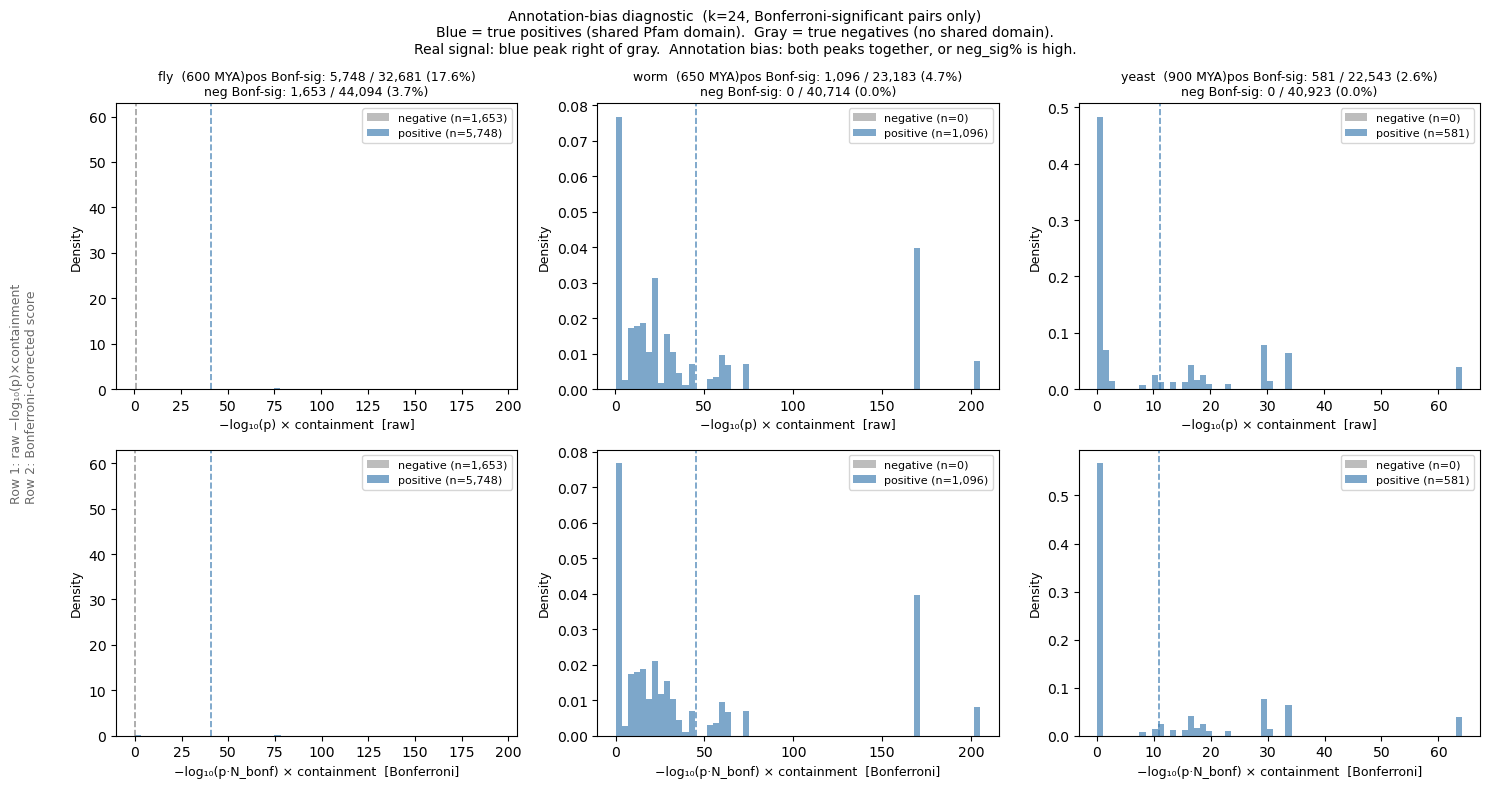

In [62]:
# ── 1. Pfam coverage + detection rates at k=24 ───────────────────────────────
focal = ["fly", "worm", "yeast"]  # 600, 650, 900 MYA
FOCAL_K = 24

header = (
    f"{'species':<12}  {'MYA':>4}  {'n_proteins':>10}  {'pct_pfam':>8}  "
    f"{'dom/prot':>8}  {'N_bonf':>12}  "
    f"{'pos_sig%':>8}  {'neg_sig%':>8}  {'pos_pairs':>9}  {'total_pairs':>11}"
)
print(header)
print("-" * len(header))

for sp in focal:
    s = PFAM_SUMMARY.get(sp, {})
    n_prot = s.get("n_qfo_canonical", 0)
    pct = s.get("pct_qfo_with_pfam", float("nan"))
    n_dom = s.get("n_total_domain_records", 0)
    dom_pp = n_dom / n_prot if n_prot else float("nan")
    n_bonf = N_HUMAN * N_PROTEINS.get(sp, 0)
    df24 = merged.get((sp, FOCAL_K))
    if df24 is not None:
        pos_df = df24.filter(pl.col("label") == 1)
        neg_df = df24.filter(pl.col("label") == 0)
        n_pos = len(pos_df)
        n_tot = len(df24)
        pos_sig = pos_df.filter(pl.col("bonf_pvalue") < 0.05)
        neg_sig = neg_df.filter(pl.col("bonf_pvalue") < 0.05)
        pos_pct = 100 * len(pos_sig) / n_pos if n_pos else float("nan")
        neg_pct = 100 * len(neg_sig) / len(neg_df) if len(neg_df) else float("nan")
    else:
        n_pos = n_tot = "N/A"
        pos_pct = neg_pct = float("nan")
    print(
        f"{sp:<12}  {META[sp]['mya']:>4}  {n_prot:>10,}  {pct:>8.1f}  "
        f"{dom_pp:>8.2f}  {n_bonf:>12,}  "
        f"{pos_pct:>7.1f}%  {neg_pct:>7.1f}%  "
        f"{str(n_pos):>9}  {str(n_tot):>11}"
    )

print()
print("pos_sig%: % of true-positive pairs (shared Pfam domain) passing Bonferroni")
print("neg_sig%: % of true-negative pairs (no shared Pfam domain) passing Bonferroni")
print("Annotation bias signal: neg_sig% >> 0 means negatives are also being flagged,")
print("  which inflates AUC. Real signal: pos_sig% >> neg_sig%.")

# ── 2. Score distributions among Bonferroni-significant pairs ─────────────────
# Each panel shows how scores are distributed for true-positive pairs (blue,
# human-species protein pairs that SHARE a Pfam domain) vs true-negative pairs
# (gray, pairs that do NOT share a Pfam domain), restricted to pairs that pass
# Bonferroni correction (bonf_pvalue < 0.05).
#
# What to look for:
#   Real signal     → blue (positive) peak is to the RIGHT of gray (negative)
#   Annotation bias → both peaks at similar positions; separation comes from
#                     more positives being detected, not higher scores
#
# Row 1 (uncorrected): raw -log10(p) * containment score
# Row 2 (Bonferroni):  same score after applying Bonferroni correction to p

FOCAL_K = 24
fig, axes = plt.subplots(2, len(focal), figsize=(5 * len(focal), 8))

for col_i, sp in enumerate(focal):
    df = merged.get((sp, FOCAL_K))
    mya = META[sp]["mya"]
    if df is None:
        for row_i in range(2):
            axes[row_i, col_i].set_title(f"{sp} ({mya} MYA) — no data")
        continue

    sig = df.filter(pl.col("bonf_pvalue") < 0.05)
    pos = sig.filter(pl.col("label") == 1)
    neg = sig.filter(pl.col("label") == 0)

    # Fraction of ground-truth pairs that are Bonferroni-significant
    n_pos_all = int(df["label"].sum())
    n_neg_all = len(df) - n_pos_all
    pos_pct_sig = 100 * len(pos) / n_pos_all if n_pos_all else 0
    neg_pct_sig = 100 * len(neg) / n_neg_all if n_neg_all else 0

    col_title = (
        f"{sp}  ({mya} MYA)"
        f"pos Bonf-sig: {len(pos):,} / {n_pos_all:,} ({pos_pct_sig:.1f}%)\n"
        f"neg Bonf-sig: {len(neg):,} / {n_neg_all:,} ({neg_pct_sig:.1f}%)"
    )

    for row_i, (score_col, xlabel) in enumerate(
        [
            ("score_neglogp_cont", "−log₁₀(p) × containment  [raw]"),
            ("score_bonf_neglogp_cont", "−log₁₀(p·N_bonf) × containment  [Bonferroni]"),
        ]
    ):
        ax = axes[row_i, col_i]
        p_vals = pos[score_col].to_numpy()
        n_vals = neg[score_col].to_numpy()
        ax.hist(
            n_vals,
            bins=60,
            alpha=0.55,
            label=f"negative (n={len(n_vals):,})",
            color="#888888",
            density=True,
        )
        ax.hist(
            p_vals,
            bins=60,
            alpha=0.70,
            label=f"positive (n={len(p_vals):,})",
            color="steelblue",
            density=True,
        )
        if row_i == 0:
            ax.set_title(col_title, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8)
        # Annotate means
        if len(p_vals):
            ax.axvline(
                p_vals.mean(),
                color="steelblue",
                linestyle="--",
                linewidth=1.2,
                alpha=0.8,
            )
        if len(n_vals):
            ax.axvline(
                n_vals.mean(), color="#888888", linestyle="--", linewidth=1.2, alpha=0.8
            )

fig.text(
    0.01,
    0.5,
    "Row 1: raw −log₁₀(p)×containment\nRow 2: Bonferroni-corrected score",
    va="center",
    rotation="vertical",
    fontsize=9,
    color="dimgray",
)
plt.suptitle(
    "Annotation-bias diagnostic  (k=24, Bonferroni-significant pairs only)\n"
    "Blue = true positives (shared Pfam domain).  Gray = true negatives (no shared domain).\n"
    "Real signal: blue peak right of gray.  Annotation bias: both peaks together, "
    "or neg_sig% is high.",
    fontsize=10,
)
plt.tight_layout(rect=[0.04, 0, 1, 1])
plt.show()

In [63]:
# Save merged parquets (one per species × ksize)
for (sp, ksize), df in merged.items():
    out = MERGED_DIR / f"human_vs_{sp}.hp.k{ksize}.merged.parquet"
    df.write_parquet(out, compression="snappy")
print(f"Saved {len(merged)} merged parquets to {MERGED_DIR}/")

Saved 99 merged parquets to ../results/pfam_benchmark/merged/


## Compute AUC for all (species × ksize × score)

In [64]:
def compute_aucs(df: pl.DataFrame) -> dict:
    y = df["label"].cast(pl.Int8).to_numpy()
    if y.sum() == 0 or (1 - y).sum() == 0:
        return {}
    out = {}
    for col in SCORE_COLS:
        if col not in df.columns:
            continue
        scores = df[col].fill_null(0.0).fill_nan(0.0).to_numpy()
        try:
            out[col] = {
                "roc_auc": roc_auc_score(y, scores),
                "pr_auc": average_precision_score(y, scores),
            }
        except Exception:
            pass
    return out


auc_records = []
for (sp, ksize), df in merged.items():
    for score_col, vals in compute_aucs(df).items():
        auc_records.append(
            {
                "species": sp,
                "mya": META[sp]["mya"],
                "ksize": ksize,
                "score_col": score_col,
                "roc_auc": vals["roc_auc"],
                "pr_auc": vals["pr_auc"],
            }
        )

print(f"auc_records count: {len(auc_records)}")
if not auc_records:
    print(f"  merged dict has {len(merged)} entries")
    for key, df in list(merged.items())[:3]:
        print(
            f"  {key}: columns={df.columns}, label counts={df['label'].value_counts()}"
        )

AUC_SCHEMA = {
    "species": pl.Utf8,
    "mya": pl.Int64,
    "ksize": pl.Int64,
    "score_col": pl.Utf8,
    "roc_auc": pl.Float64,
    "pr_auc": pl.Float64,
}
# Use schema= only (not data=[]) when records are empty to avoid Polars creating 0-column DataFrame
auc_df = (
    pl.DataFrame(auc_records, schema=AUC_SCHEMA)
    if auc_records
    else pl.DataFrame(schema=AUC_SCHEMA)
)
auc_df.write_parquet(
    MERGED_DIR / "auc_by_species_ksize_score.parquet", compression="snappy"
)
print(auc_df.sort(["ksize", "mya", "score_col"]))

auc_records count: 1188
shape: (1_188, 6)
┌─────────┬──────┬───────┬─────────────────────────┬─────────┬──────────┐
│ species ┆ mya  ┆ ksize ┆ score_col               ┆ roc_auc ┆ pr_auc   │
│ ---     ┆ ---  ┆ ---   ┆ ---                     ┆ ---     ┆ ---      │
│ str     ┆ i64  ┆ i64   ┆ str                     ┆ f64     ┆ f64      │
╞═════════╪══════╪═══════╪═════════════════════════╪═════════╪══════════╡
│ mouse   ┆ 100  ┆ 10    ┆ containment             ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ enrichment              ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ jaccard                 ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ score_bh_neglogq        ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ score_bh_neglogq_cont   ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ score_bonf_neglogp      ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ score_bonf_neglogp_cont ┆ 0.5     ┆ 0.333333 │
│ mouse   ┆ 100  ┆ 10    ┆ score_enr_cont          ┆ 0.5     ┆ 0.33333

In [65]:
auc_df.filter((pl.col("species") == "ecoli") & (pl.col("ksize") == 20)).sort(["pr_auc"])

species,mya,ksize,score_col,roc_auc,pr_auc
str,i64,i64,str,f64,f64
"""ecoli""",2000,20,"""score_bonf_neglogp_cont""",0.505532,0.212531
"""ecoli""",2000,20,"""score_bonf_neglogp""",0.505532,0.212531
"""ecoli""",2000,20,"""score_bh_neglogq_cont""",0.507853,0.216251
"""ecoli""",2000,20,"""score_bh_neglogq""",0.507854,0.216459
"""ecoli""",2000,20,"""score_enr_cont_freq""",0.563223,0.255154
"""ecoli""",2000,20,"""enrichment""",0.563242,0.255885
"""ecoli""",2000,20,"""score_enr_cont""",0.563331,0.257167
"""ecoli""",2000,20,"""containment""",0.563442,0.257317
"""ecoli""",2000,20,"""jaccard""",0.563451,0.260015


## Figure 1a: THE KEY FIGURE — AUC vs MYA, one line per k-size

Shows the effective evolutionary range of each HP k-size for subdomain detection.
Uses the best composite scoring method (determined from Figure 1b).

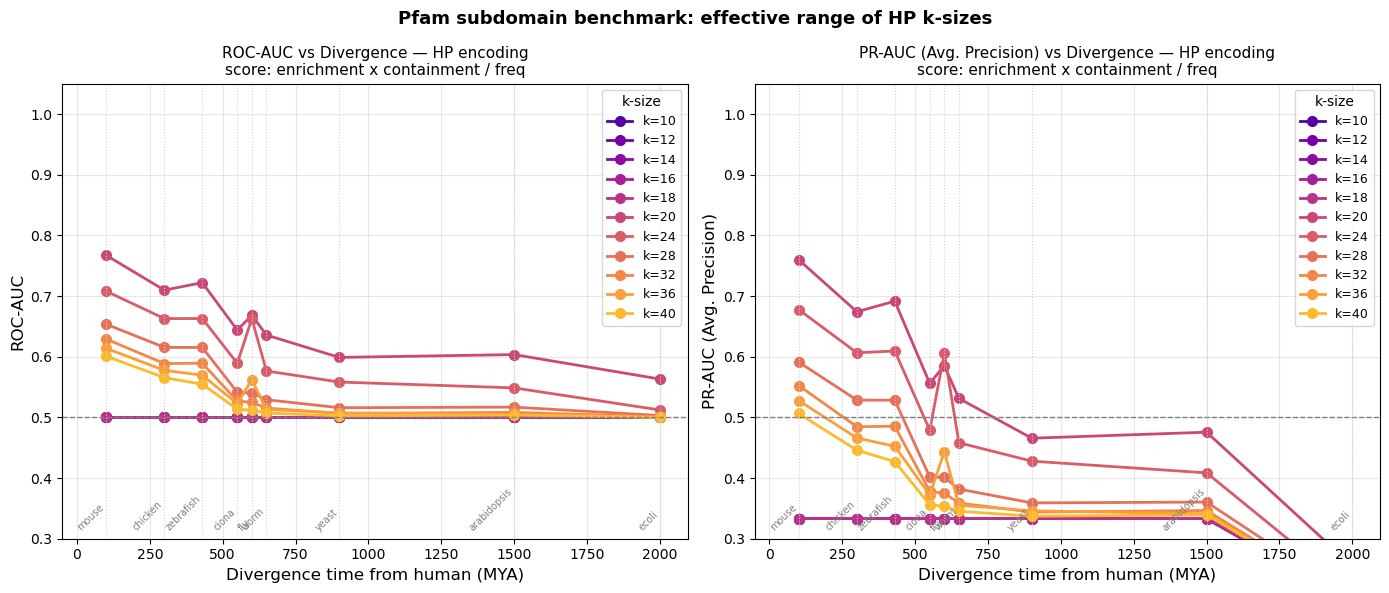

In [66]:
# Pick the score to use for the k-size comparison.
# Change BEST_SCORE after inspecting Figure 1b.
BEST_SCORE = "score_enr_cont_freq"

KSIZE_COLORS = plt.cm.plasma(np.linspace(0.15, 0.85, len(KSIZES)))
KSIZE_COLOR = {k: c for k, c in zip(KSIZES, KSIZE_COLORS)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in zip(
    axes, ["roc_auc", "pr_auc"], ["ROC-AUC", "PR-AUC (Avg. Precision)"]
):
    sub_all = auc_df.filter(pl.col("score_col") == BEST_SCORE)
    for ksize in KSIZES:
        sub = sub_all.filter(pl.col("ksize") == ksize).sort("mya")
        if sub.is_empty():
            continue
        ax.plot(
            sub["mya"].to_numpy(),
            sub[metric].to_numpy(),
            "o-",
            label=f"k={ksize}",
            color=KSIZE_COLOR[ksize],
            linewidth=2,
            markersize=7,
        )

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Divergence time from human (MYA)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(
        f"{ylabel} vs Divergence — HP encoding\n" f"score: {SCORE_LABELS[BEST_SCORE]}",
        fontsize=11,
    )
    ax.set_xlim(left=-50)
    ax.set_ylim(0.3, 1.05)
    ax.legend(title="k-size", fontsize=9)
    ax.grid(True, alpha=0.3)
    for sp in sp_found:
        ax.axvline(META[sp]["mya"], color="lightgray", linestyle=":", linewidth=0.8)
        ax.text(
            META[sp]["mya"],
            0.31,
            sp,
            rotation=45,
            fontsize=7,
            ha="right",
            va="bottom",
            color="gray",
        )

plt.suptitle(
    "Pfam subdomain benchmark: effective range of HP k-sizes",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    BENCHMARK_DIR / "fig1a_auc_vs_divergence_by_ksize.pdf", dpi=150, bbox_inches="tight"
)
plt.savefig(
    BENCHMARK_DIR / "fig1a_auc_vs_divergence_by_ksize.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Figure 1b: AUC vs MYA, one line per scoring method (fixed k)

Shows which scoring method works best. Use this to choose `BEST_SCORE` above.

## Figure 1c: AUC vs MYA — raw vs Bonferroni vs BH correction (fixed k)

Compares the three p-value correction strategies at a fixed k-size.
Each line is one correction type; both `score × containment` variants are shown.

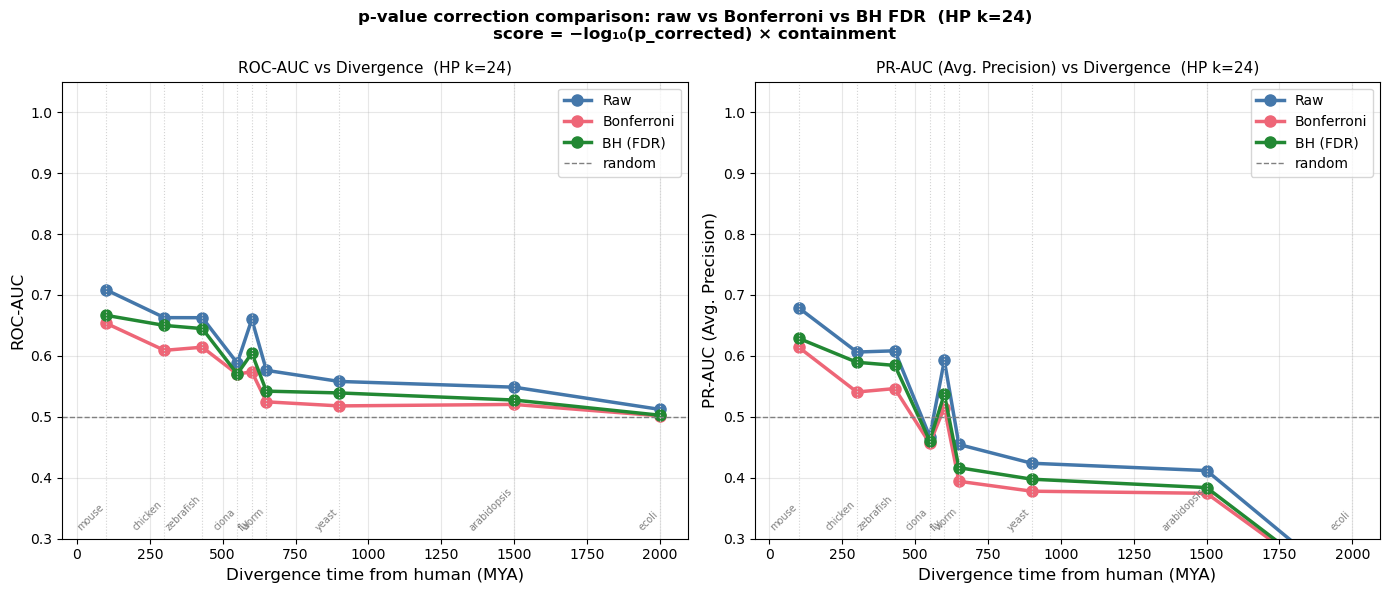

In [67]:
# Compare raw, Bonferroni, and BH p-value corrections at a fixed k.
# Each uses the "neglogp * containment" score variant for a fair apples-to-apples comparison.
FOCAL_KSIZE = 24

CORRECTION_SCORES = {
    "Raw": "score_neglogp_cont",
    "Bonferroni": "score_bonf_neglogp_cont",
    "BH (FDR)": "score_bh_neglogq_cont",
}
CORRECTION_COLORS = {
    "Raw": "#4477AA",
    "Bonferroni": "#EE6677",
    "BH (FDR)": "#228833",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in zip(
    axes, ["roc_auc", "pr_auc"], ["ROC-AUC", "PR-AUC (Avg. Precision)"]
):
    sub_k = auc_df.filter(pl.col("ksize") == FOCAL_KSIZE)
    for label, score_col in CORRECTION_SCORES.items():
        sub = sub_k.filter(pl.col("score_col") == score_col).sort("mya")
        if sub.is_empty():
            continue
        ax.plot(
            sub["mya"].to_numpy(),
            sub[metric].to_numpy(),
            "o-",
            label=label,
            color=CORRECTION_COLORS[label],
            linewidth=2.5,
            markersize=8,
        )

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random")
    ax.set_xlabel("Divergence time from human (MYA)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"{ylabel} vs Divergence  (HP k={FOCAL_KSIZE})", fontsize=11)
    ax.set_xlim(left=-50)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    for sp in sp_found:
        ax.axvline(META[sp]["mya"], color="lightgray", linestyle=":", linewidth=0.8)
        ax.text(
            META[sp]["mya"],
            0.31,
            sp,
            rotation=45,
            fontsize=7,
            ha="right",
            va="bottom",
            color="gray",
        )

plt.suptitle(
    f"p-value correction comparison: raw vs Bonferroni vs BH FDR  (HP k={FOCAL_KSIZE})\n"
    "score = −log₁₀(p_corrected) × containment",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    BENCHMARK_DIR / f"fig1c_auc_correction_comparison_k{FOCAL_KSIZE}.pdf",
    dpi=150,
    bbox_inches="tight",
)
plt.savefig(
    BENCHMARK_DIR / f"fig1c_auc_correction_comparison_k{FOCAL_KSIZE}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

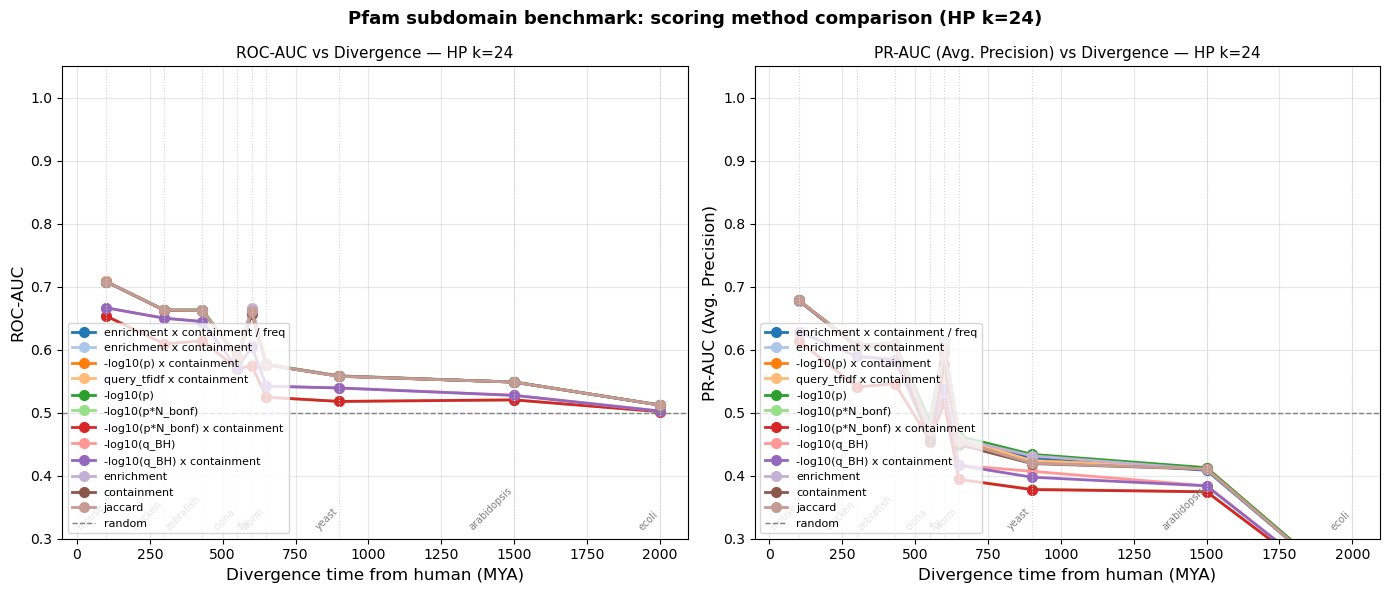

In [68]:
FOCAL_KSIZE = 24  # adjust as desired

COLOR_CYCLE = plt.get_cmap("tab20").colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in zip(
    axes, ["roc_auc", "pr_auc"], ["ROC-AUC", "PR-AUC (Avg. Precision)"]
):
    sub_k = auc_df.filter(pl.col("ksize") == FOCAL_KSIZE)
    for i, score_col in enumerate(SCORE_COLS):
        sub = sub_k.filter(pl.col("score_col") == score_col).sort("mya")
        if sub.is_empty():
            continue
        ax.plot(
            sub["mya"].to_numpy(),
            sub[metric].to_numpy(),
            "o-",
            label=SCORE_LABELS[score_col],
            color=COLOR_CYCLE[i % len(COLOR_CYCLE)],
            linewidth=2,
            markersize=7,
        )

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random")
    ax.set_xlabel("Divergence time from human (MYA)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"{ylabel} vs Divergence — HP k={FOCAL_KSIZE}", fontsize=11)
    ax.set_xlim(left=-50)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(True, alpha=0.3)
    for sp in sp_found:
        ax.axvline(META[sp]["mya"], color="lightgray", linestyle=":", linewidth=0.8)
        ax.text(
            META[sp]["mya"],
            0.31,
            sp,
            rotation=45,
            fontsize=7,
            ha="right",
            va="bottom",
            color="gray",
        )

plt.suptitle(
    f"Pfam subdomain benchmark: scoring method comparison (HP k={FOCAL_KSIZE})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    BENCHMARK_DIR / f"fig1b_auc_vs_divergence_scoring_k{FOCAL_KSIZE}.pdf",
    dpi=150,
    bbox_inches="tight",
)
plt.savefig(
    BENCHMARK_DIR / f"fig1b_auc_vs_divergence_scoring_k{FOCAL_KSIZE}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Figure 2: Per-species ROC & PR curves (best k, best score)

In [69]:
# Best ksize = whichever gives highest mean ROC-AUC across species for BEST_SCORE
mean_auc_by_k = (
    auc_df.filter(pl.col("score_col") == BEST_SCORE)
    .group_by("ksize")
    .agg(pl.col("roc_auc").mean().alias("mean_roc_auc"))
    .sort("mean_roc_auc", descending=True)
)
print("Mean ROC-AUC by k-size:")
print(mean_auc_by_k)
BEST_KSIZE = mean_auc_by_k["ksize"][0]
print(f"\nUsing best k={BEST_KSIZE} for per-species plots")

Mean ROC-AUC by k-size:
shape: (11, 2)
┌───────┬──────────────┐
│ ksize ┆ mean_roc_auc │
│ ---   ┆ ---          │
│ i64   ┆ f64          │
╞═══════╪══════════════╡
│ 20    ┆ 0.656981     │
│ 24    ┆ 0.609047     │
│ 28    ┆ 0.559024     │
│ 32    ┆ 0.543353     │
│ 36    ┆ 0.541241     │
│ 40    ┆ 0.528865     │
│ 16    ┆ 0.5          │
│ 10    ┆ 0.5          │
│ 18    ┆ 0.5          │
│ 12    ┆ 0.5          │
│ 14    ┆ 0.5          │
└───────┴──────────────┘

Using best k=20 for per-species plots


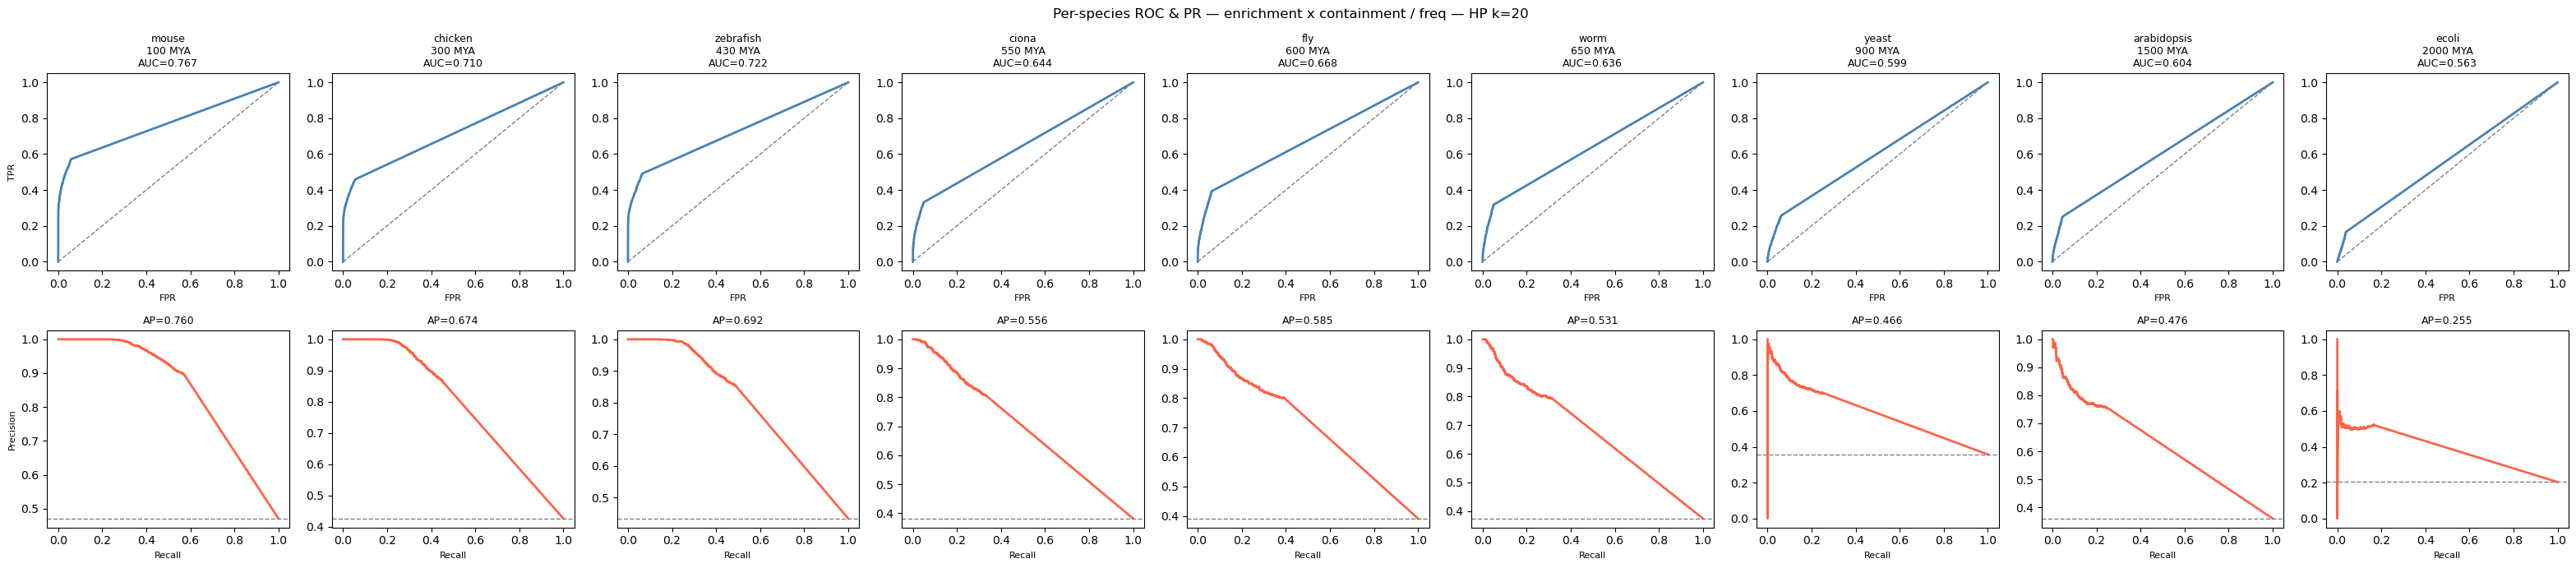

In [70]:
species_with_data = [s for s in SPECIES_ORDER if (s, BEST_KSIZE) in merged]
n_sp = len(species_with_data)

fig, axes = plt.subplots(2, n_sp, figsize=(3.5 * n_sp, 7))
if n_sp == 1:
    axes = axes.reshape(2, 1)

for col_i, sp in enumerate(species_with_data):
    df = merged[(sp, BEST_KSIZE)]
    y = df["label"].cast(pl.Int8).to_numpy()
    scr = df[BEST_SCORE].fill_null(0.0).fill_nan(0.0).to_numpy()

    # ROC
    ax = axes[0, col_i]
    try:
        fpr, tpr, _ = roc_curve(y, scr)
        auc_v = roc_auc_score(y, scr)
        ax.plot(fpr, tpr, lw=2, color="steelblue")
        ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
        ax.set_title(f"{sp}\n{META[sp]['mya']} MYA\nAUC={auc_v:.3f}", fontsize=9)
    except Exception:
        ax.set_title(f"{sp}\n(no data)", fontsize=9)
    ax.set_xlabel("FPR", fontsize=8)
    if col_i == 0:
        ax.set_ylabel("TPR", fontsize=8)

    # PR
    ax = axes[1, col_i]
    try:
        prec, rec, _ = precision_recall_curve(y, scr)
        ap = average_precision_score(y, scr)
        ax.plot(rec, prec, lw=2, color="tomato")
        ax.axhline(y.sum() / len(y), color="gray", linestyle="--", lw=1)
        ax.set_title(f"AP={ap:.3f}", fontsize=9)
    except Exception:
        pass
    ax.set_xlabel("Recall", fontsize=8)
    if col_i == 0:
        ax.set_ylabel("Precision", fontsize=8)

plt.suptitle(
    f"Per-species ROC & PR — {SCORE_LABELS[BEST_SCORE]} — HP k={BEST_KSIZE}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(
    BENCHMARK_DIR / f"fig2_per_species_roc_pr_k{BEST_KSIZE}.pdf",
    dpi=150,
    bbox_inches="tight",
)
plt.savefig(
    BENCHMARK_DIR / f"fig2_per_species_roc_pr_k{BEST_KSIZE}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Figure 3: Domain length × detection rate, faceted by divergence distance

Uses ground-truth domain lengths from the annotation parquets.
Results pooled across k-sizes (ground truth is k-size independent;
detection is shown for each k-size as separate bars).

In [71]:
LENGTH_BINS = [0, 30, 50, 100, 150, 300, 10_000]
LENGTH_LABELS = ["<30", "30–50", "50–100", "100–150", "150–300", ">300"]
MYA_NEAR = 500

len_records = []

for sp in sp_found:
    dom_path = ANNOT_DIR / f"{sp}_pfam_domains.parquet"
    h_dom_path = ANNOT_DIR / "human_pfam_domains.parquet"
    if not dom_path.exists() or not h_dom_path.exists():
        continue

    med_len = (
        pl.concat(
            [
                pl.read_parquet(dom_path)
                .select(["pfam_id", "domain_length"])
                .drop_nulls(),
                pl.read_parquet(h_dom_path)
                .select(["pfam_id", "domain_length"])
                .drop_nulls(),
            ]
        )
        .group_by("pfam_id")
        .agg(pl.col("domain_length").median().alias("median_domain_length"))
    )

    for ksize in KSIZES:
        if (sp, ksize) not in merged:
            continue
        df = merged[(sp, ksize)]
        pos_df = (
            df.filter(pl.col("label") & (pl.col("shared_pfam_ids") != ""))
            .with_columns(pl.col("shared_pfam_ids").str.split(";").alias("pfam_list"))
            .explode("pfam_list")
            .rename({"pfam_list": "pfam_id"})
            .join(med_len, on="pfam_id", how="left")
        )
        for row in pos_df.iter_rows(named=True):
            dl = row.get("median_domain_length")
            if dl is None:
                continue
            len_records.append(
                {
                    "species": sp,
                    "mya": META[sp]["mya"],
                    "ksize": ksize,
                    "pfam_id": row["pfam_id"],
                    "domain_length": dl,
                    "containment": row["containment"],
                    "detected": row["containment"] > 0,
                    "divergence_group": (
                        "near (<500 MYA)"
                        if META[sp]["mya"] < MYA_NEAR
                        else "far (≥500 MYA)"
                    ),
                }
            )

if len_records:
    len_df = pl.DataFrame(len_records).with_columns(
        pl.col("domain_length")
        .cut(breaks=LENGTH_BINS[1:-1], labels=LENGTH_LABELS)
        .alias("length_bin")
    )
    len_df.write_parquet(
        MERGED_DIR / "domain_length_analysis.parquet", compression="snappy"
    )

    # Plot: one panel per divergence group, bars grouped by ksize
    div_groups = ["near (<500 MYA)", "far (≥500 MYA)"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    bar_width = 0.8 / len(KSIZES)
    x = np.arange(len(LENGTH_LABELS))

    for ax, grp in zip(axes, div_groups):
        sub = len_df.filter(pl.col("divergence_group") == grp)
        for ki, ksize in enumerate(KSIZES):
            rates = []
            for lbl in LENGTH_LABELS:
                cell = sub.filter(
                    (pl.col("ksize") == ksize) & (pl.col("length_bin") == lbl)
                )
                rates.append(cell["detected"].mean() if cell.height > 0 else 0.0)
            offset = (ki - len(KSIZES) / 2 + 0.5) * bar_width
            ax.bar(
                x + offset,
                rates,
                width=bar_width,
                label=f"k={ksize}",
                color=KSIZE_COLOR[ksize],
                alpha=0.85,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(LENGTH_LABELS, fontsize=9)
        ax.set_title(f"Detection rate — {grp}", fontsize=11)
        ax.set_xlabel("Shared domain length (aa)", fontsize=10)
        ax.set_ylabel("Fraction detected (containment > 0)", fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, axis="y", alpha=0.3)

    plt.suptitle(
        "Domain length vs detection rate by HP k-size and divergence", fontsize=12
    )
    plt.tight_layout()
    plt.savefig(
        BENCHMARK_DIR / "fig3_domain_length_detection.pdf", dpi=150, bbox_inches="tight"
    )
    plt.savefig(
        BENCHMARK_DIR / "fig3_domain_length_detection.png", dpi=150, bbox_inches="tight"
    )
    plt.show()
else:
    print("No domain length data — run build_pfam_architectures.py first.")

No domain length data — run build_pfam_architectures.py first.


## Figure 4: Score distribution violins — positives vs negatives, per species (best k)

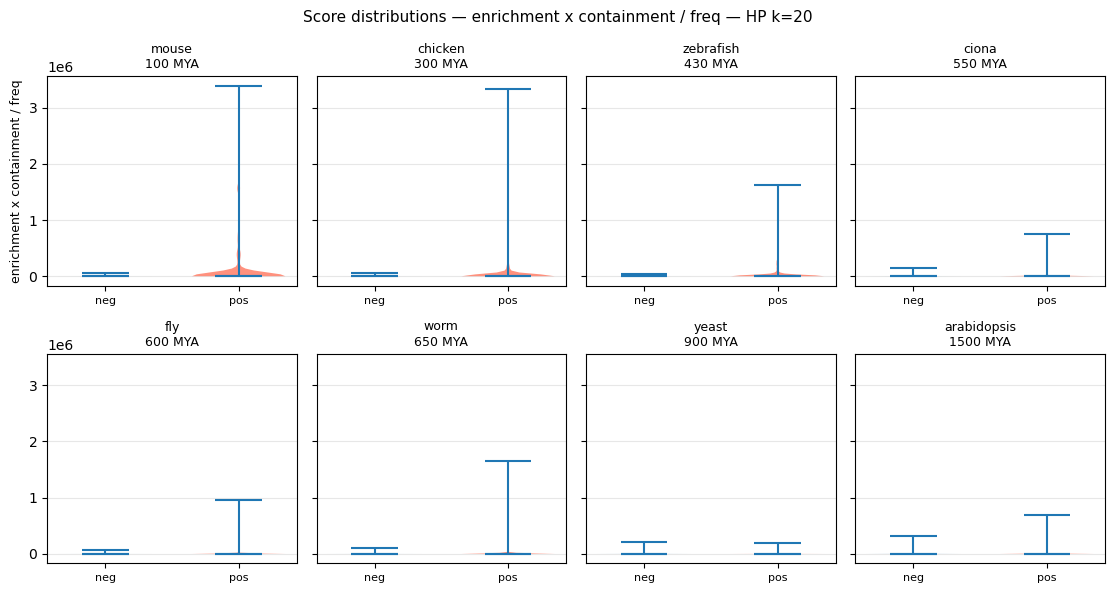

In [72]:
fig, axes = plt.subplots(2, n_sp // 2, figsize=(2.5 * n_sp / 2, 6), sharey=True)
if n_sp == 1:
    axes = [axes]

for ax, sp in zip(axes.flat, species_with_data):
    df = merged[(sp, BEST_KSIZE)]
    pos = df.filter(pl.col("label"))[BEST_SCORE].fill_null(0).fill_nan(0).to_numpy()
    neg = df.filter(~pl.col("label"))[BEST_SCORE].fill_null(0).fill_nan(0).to_numpy()

    vp = ax.violinplot([neg, pos], positions=[0, 1], showmedians=True, widths=0.7)
    for pc, color in zip(vp["bodies"], ["steelblue", "tomato"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    ax.set_title(f"{sp}\n{META[sp]['mya']} MYA", fontsize=9)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["neg", "pos"], fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

axes[0, 0].set_ylabel(SCORE_LABELS[BEST_SCORE], fontsize=9)
plt.suptitle(
    f"Score distributions — {SCORE_LABELS[BEST_SCORE]} — HP k={BEST_KSIZE}", fontsize=11
)
plt.tight_layout()
plt.savefig(
    BENCHMARK_DIR / f"fig4_score_distributions_k{BEST_KSIZE}.pdf",
    dpi=150,
    bbox_inches="tight",
)
plt.savefig(
    BENCHMARK_DIR / f"fig4_score_distributions_k{BEST_KSIZE}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Summary table

In [73]:
summary_rows = []
for sp in SPECIES_ORDER:
    for ksize in KSIZES:
        if (sp, ksize) not in merged:
            continue
        df = merged[(sp, ksize)]
        n_pos = int(df["label"].sum())
        n_neg = len(df) - n_pos
        n_hit = int((df["containment"] > 0).sum())

        row_auc = auc_df.filter(
            (pl.col("species") == sp)
            & (pl.col("ksize") == ksize)
            & (pl.col("score_col") == BEST_SCORE)
        )
        roc = row_auc["roc_auc"].item() if not row_auc.is_empty() else float("nan")
        pr = row_auc["pr_auc"].item() if not row_auc.is_empty() else float("nan")

        summary_rows.append(
            {
                "species": sp,
                "mya": META[sp]["mya"],
                "ksize": ksize,
                "n_pos": n_pos,
                "n_neg": n_neg,
                "n_hit": n_hit,
                "hit_rate": round(n_hit / max(len(df), 1), 3),
                "roc_auc": round(roc, 4),
                "pr_auc": round(pr, 4),
            }
        )

summary_table = pl.DataFrame(summary_rows)
summary_table.write_parquet(MERGED_DIR / "summary_table.parquet", compression="snappy")
summary_table.sort(["mya", "ksize"])

species,mya,ksize,n_pos,n_neg,n_hit,hit_rate,roc_auc,pr_auc
str,i64,i64,i64,i64,i64,f64,f64,f64
"""mouse""",100,10,20000,40000,0,0.0,0.5,0.3333
"""mouse""",100,12,20000,40000,0,0.0,0.5,0.3333
"""mouse""",100,14,20000,40000,0,0.0,0.5,0.3333
"""mouse""",100,16,20000,40000,0,0.0,0.5,0.3333
"""mouse""",100,18,20000,40000,0,0.0,0.5,0.3333
"""mouse""",100,20,35920,40413,22955,0.301,0.7673,0.76
"""mouse""",100,24,32208,40441,14308,0.197,0.7081,0.6778
"""mouse""",100,28,27748,40007,8568,0.126,0.6536,0.5912
"""mouse""",100,32,26286,40001,6797,0.103,0.6292,0.5525
